In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import re

from pathlib import Path
from datetime import datetime

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load territory data
terr = pd.read_csv('processed_data/territory_data.csv')

## Parse dates
terr['date'] = pd.to_datetime(terr['Date'], format='%Y-%b')

## Pivot to wide so we have one row per timepoint
wide = (terr.pivot_table(index='date', columns='Lek', values='Prop', aggfunc='mean').sort_index()
        .rename(columns={1: 'prop_lek1', 2: 'prop_lek2'}))
wide.head()

Lek,prop_lek1,prop_lek2
date,,
2013-12-01,1.000000,0.000000
2014-02-01,0.744898,0.255102
2014-10-01,0.973684,0.026316
2015-05-01,0.522013,0.477987
2015-11-01,0.720588,0.279412


In [4]:
## Colour palettes
fill_cols = {'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

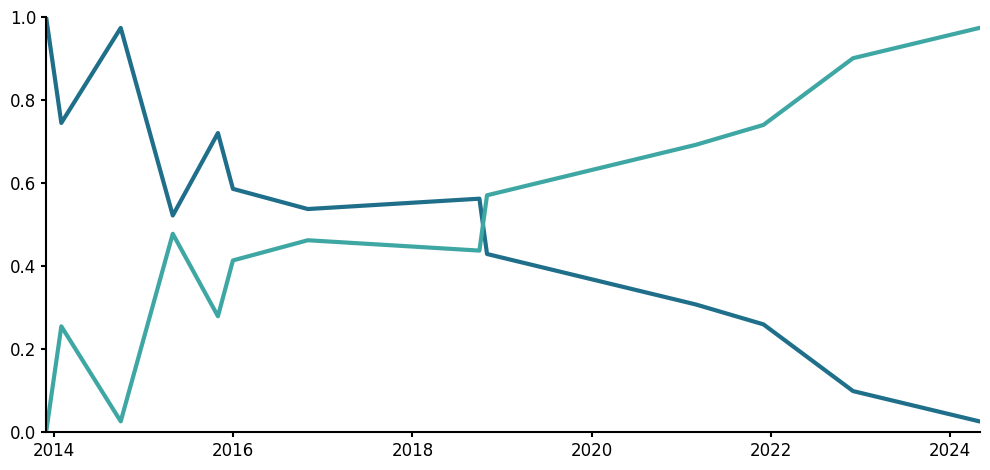

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))

## Plot the two sites over time
ax.plot(wide.index, wide['prop_lek1'], color=fill_cols['Velavadar Lek 1'], linewidth=3)
ax.plot(wide.index, wide['prop_lek2'], color=fill_cols['Velavadar Lek 2'], linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel('', fontsize=14)
ax.set_xlabel('', fontsize=14)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.margins(x=0)
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'transition_data.png', dpi=300)

In [6]:
## Month look-up chart
month_lookup = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6, 
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}

## Parse date from file label
def parse_yyMMM(label):
    '''
    Convert labels like '13DEC' or '14FEB' into a pandas Timestamp
    '''
    m = re.match(r'^(\d{2})([A-Z]{3})$', label.upper())
    if m is None:
        raise ValueError(f'Unrecognized date label: {label}')
        
    yy = int(m.group(1))
    mon = month_lookup[m.group(2)]
    return pd.Timestamp(datetime(2000 + yy, mon, 1))

def read_lek_csv(date_dir, date_label, lek_num):
    '''
    Read csv without raising an error if csv was not found
    '''
    f = date_dir / f'{date_label}_LEK{lek_num}.csv'
    if not f.exists():
        return None
    
    df = pd.read_csv(f)
    
    return df[['latitude', 'longitude']].copy()

In [7]:
# Discover date folders
base_dir = Path('rawdata/Velavadar')
data_dirs = sorted([p for p in base_dir.glob('*_COORDINATES') if p.is_dir()])

# Collect per-date point sets
date_records = []
for d in data_dirs:
    date_label = d.name.replace('_COORDINATES', '').upper()
    date_ts = parse_yyMMM(date_label)

    df1 = read_lek_csv(d, date_label, 1)
    df2 = read_lek_csv(d, date_label, 2)

    date_records.append({'date_label': date_label, 'date': date_ts, 'lek1': df1, 'lek2': df2})

date_records = sorted(date_records, key=lambda r: r['date'])

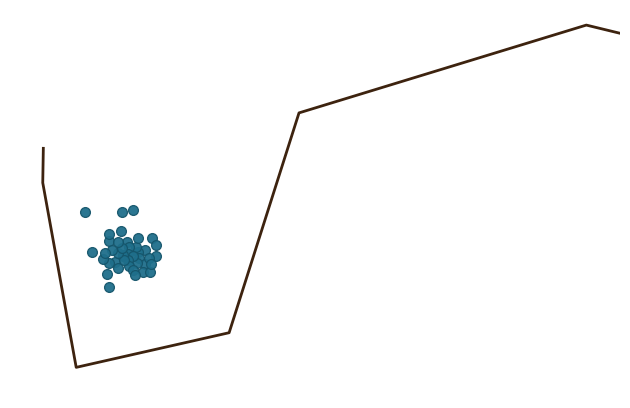

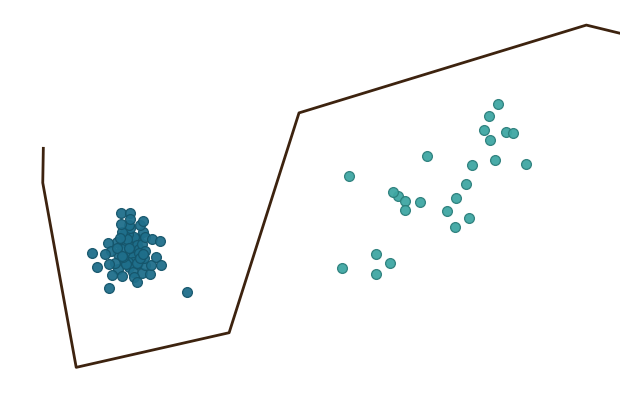

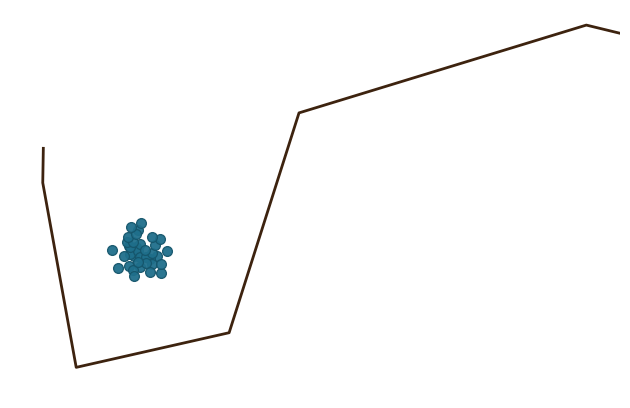

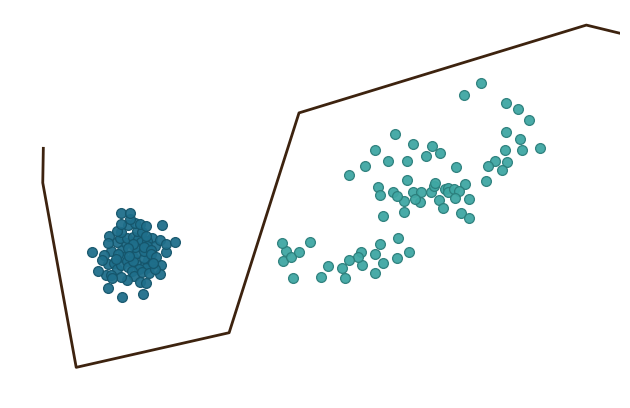

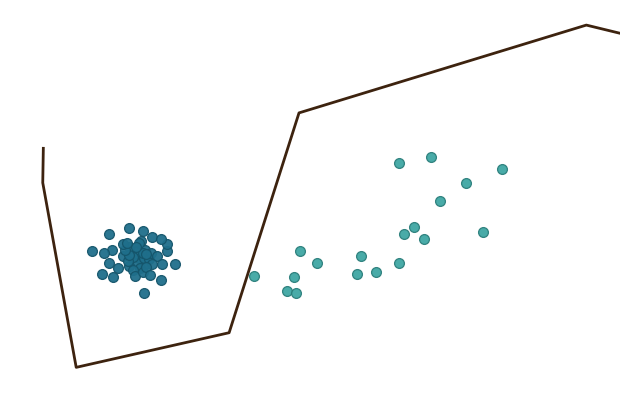

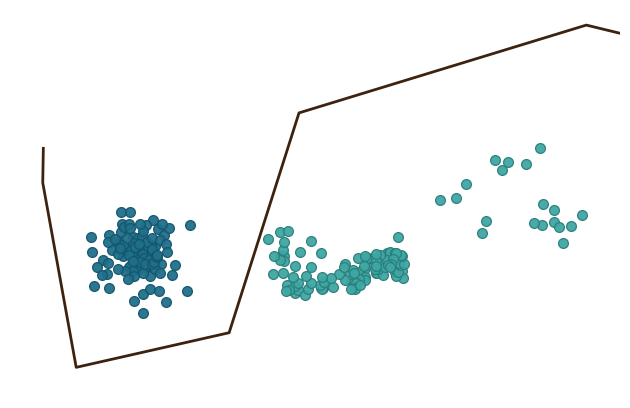

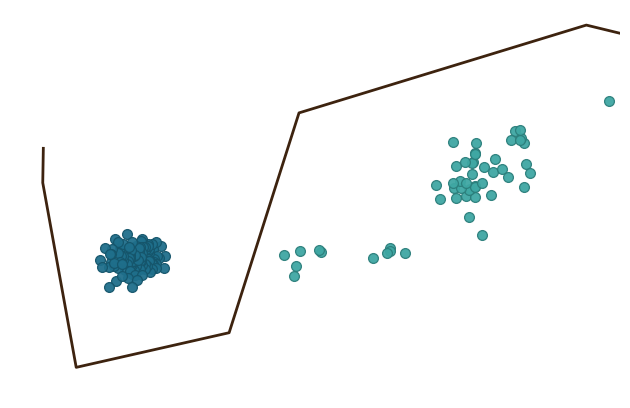

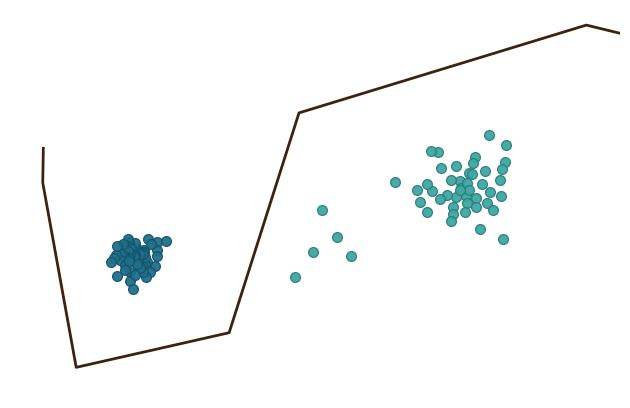

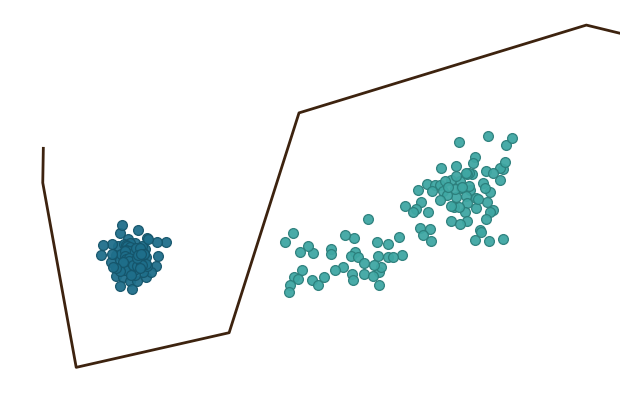

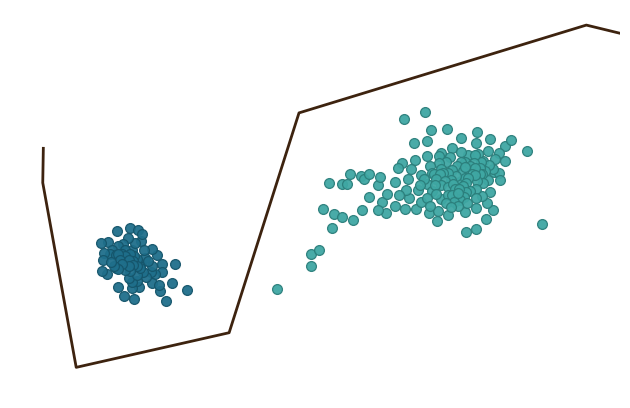

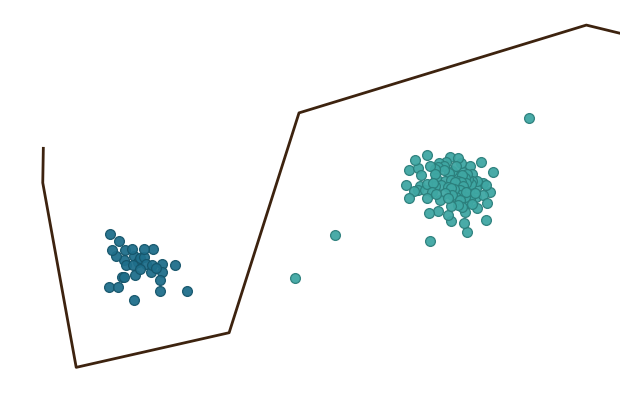

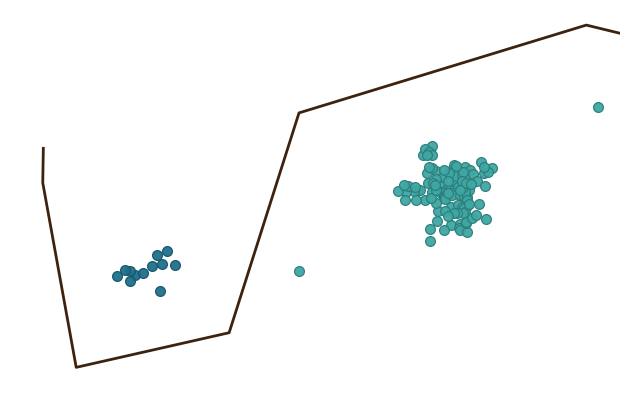

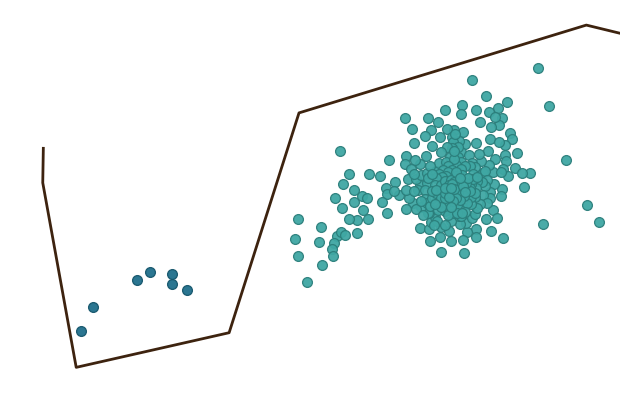

In [8]:
## Load roads and plot one figure per date
roads_gdf = gpd.read_file('rawdata/Velavadar/VelavadarRoads.shp', engine='pyogrio')

## Plot figure
for rec in date_records:
    fig, ax = plt.subplots(1,1)

    roads_gdf.plot(ax=ax, linewidth=2, color='#3D230F', zorder=1)

    if rec['lek1'] is not None:
        ax.scatter(rec['lek1']['longitude'], rec['lek1']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 1'), edgecolor=point_cols.get('Velavadar Lek 1'),
                   linewidth=0.9, alpha=0.95, zorder=3, label='Lek 1')

    if rec['lek2'] is not None:
        ax.scatter(rec['lek2']['longitude'], rec['lek2']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 2'), edgecolor=point_cols.get('Velavadar Lek 2'),
                   linewidth=0.9, alpha=0.95, zorder=4, label='Lek 2')

    ax.set_xlim(72.018,72.04) 
    ax.set_ylim(22.043,22.056)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_dir/f"territories_{rec['date_label']}.png", dpi=300)
    plt.show()

### Model the transition of males from the traditional site to the newly established site

In [ ]:
## Preference transition with innovation and copying
preference_mod = """
data {
  int<lower=2> time;
  array[time] int<lower=0> y;
  array[time] int<lower=1> N;

  vector[time] dNDVI;
}

transformed data {
  vector[time] p_obs;
  vector[time] logN;

  for (t in 1:time) {
    p_obs[t] = (y[t] + 0.0) / N[t];
    logN[t]  = log(N[t]);
  }
}

parameters {
  real alpha;
  real gamma_NDVI;
  real delta_N;

  real<lower=0, upper=1> eps;
}

transformed parameters {
  vector[time] mu;
  mu[1] = fmin(fmax(p_obs[1], 1e-6), 1 - 1e-6);

  for (t in 2:time) {
    real innov = inv_logit(alpha + gamma_NDVI * dNDVI[t-1] + delta_N * logN[t-1]);
    real copy  = p_obs[t-1];

    mu[t] = (1 - eps) * copy + eps * innov;
  }
}

model {
  alpha ~ normal(0, 1.5);
  gamma_NDVI ~ normal(0, 1.0);
  delta_N ~ normal(0, 1.0);

  // eps is the innovation rate prior
  eps ~ beta(2, 8);

  for (t in 2:time) {
    y[t] ~ binomial(N[t], mu[t]);
  }
}

generated quantities {
  array[time] int y_rep;
  vector[time] p_rep;
  real copying_strength = 1 - eps;

  // Initialize (t=1 not modeled)
  y_rep[1] = y[1];
  p_rep[1] = p_obs[1];

  for (t in 2:time) {
    y_rep[t] = binomial_rng(N[t], mu[t]);
    p_rep[t] = (y_rep[t] + 0.0) / N[t];
  }
}
"""

In [ ]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)

data_transition = {
    'time': df['t_centred'].astype(float).to_numpy(),
    'dNDVI': dNDVI_z.astype(float),
    'N': df['n_territories'].astype(int).to_numpy(),
    'y': df['n_site2'].astype(int).to_numpy()
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)